# AI304 Unsupervised Learning Lab
## Notebook 4: Visualisation & Analysis

In [1]:
# ─────────────────────────────────────────────
# Import libraries
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

# Set global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print("Libraries imported.")

Libraries imported.


In [2]:
# ─────────────────────────────────────────────
# Load clustering results from Notebook 3
# ─────────────────────────────────────────────
df = pd.read_csv("clustered_features.csv", parse_dates=True, index_col='datetime')
scaled_data = np.load("scaled_data.npy")

print(f"Loaded: {df.shape[0]} days, {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

Loaded: 1433 days, 16 columns
Columns: ['mean_power', 'max_power', 'min_power', 'std_power', 'peak_to_avg_ratio', 'avg_kitchen', 'avg_laundry', 'avg_hvac', 'mean_voltage', 'std_voltage', 'day_of_week', 'is_weekend', 'kmeans_cluster', 'kmedoids_cluster', 'dbscan_cluster', 'agg_cluster']


---
## Part A: Scatter Plots — All Four Algorithms

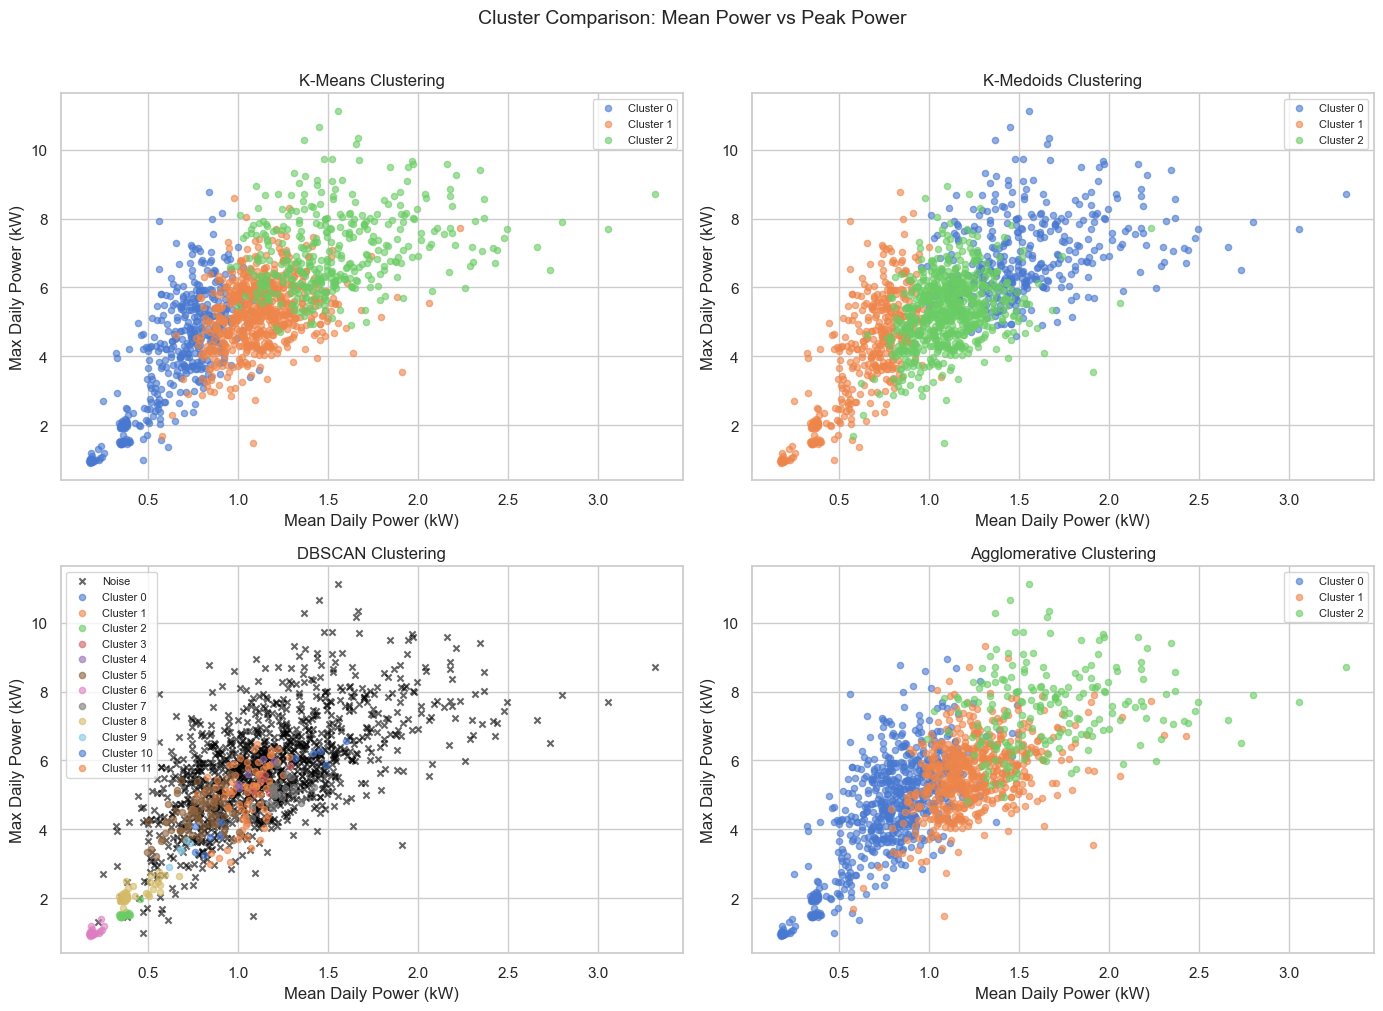

In [3]:
# ─────────────────────────────────────────────
# Side-by-side scatter plots for all four clustering algorithms
# X-axis: mean_power (average daily usage)
# Y-axis: max_power  (peak usage)
# Colour: cluster label
# For DBSCAN, noise points (label -1) are shown in black.
# ─────────────────────────────────────────────
cluster_cols = ['kmeans_cluster', 'kmedoids_cluster', 'dbscan_cluster', 'agg_cluster']
titles = ['K-Means', 'K-Medoids', 'DBSCAN', 'Agglomerative']
cmaps = ['tab10', 'tab10', 'tab10', 'tab10']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (col, title) in enumerate(zip(cluster_cols, titles)):
    ax = axes[i]
    labels = df[col].values
    unique_labels = sorted(set(labels))

    for label in unique_labels:
        mask = labels == label
        colour = 'black' if label == -1 else None  # DBSCAN noise → black
        marker = 'x' if label == -1 else 'o'
        ax.scatter(
            df.loc[mask, 'mean_power'],
            df.loc[mask, 'max_power'],
            label=f'Noise' if label == -1 else f'Cluster {label}',
            alpha=0.6,
            s=20,
            marker=marker,
            c=colour if colour else None,
        )

    ax.set_title(f"{title} Clustering", fontsize=12)
    ax.set_xlabel("Mean Daily Power (kW)")
    ax.set_ylabel("Max Daily Power (kW)")
    ax.legend(fontsize=8)

plt.suptitle("Cluster Comparison: Mean Power vs Peak Power", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## Part B: PCA Projection (2D) of Clusters

PCA variance explained: PC1=45.34%, PC2=17.88%


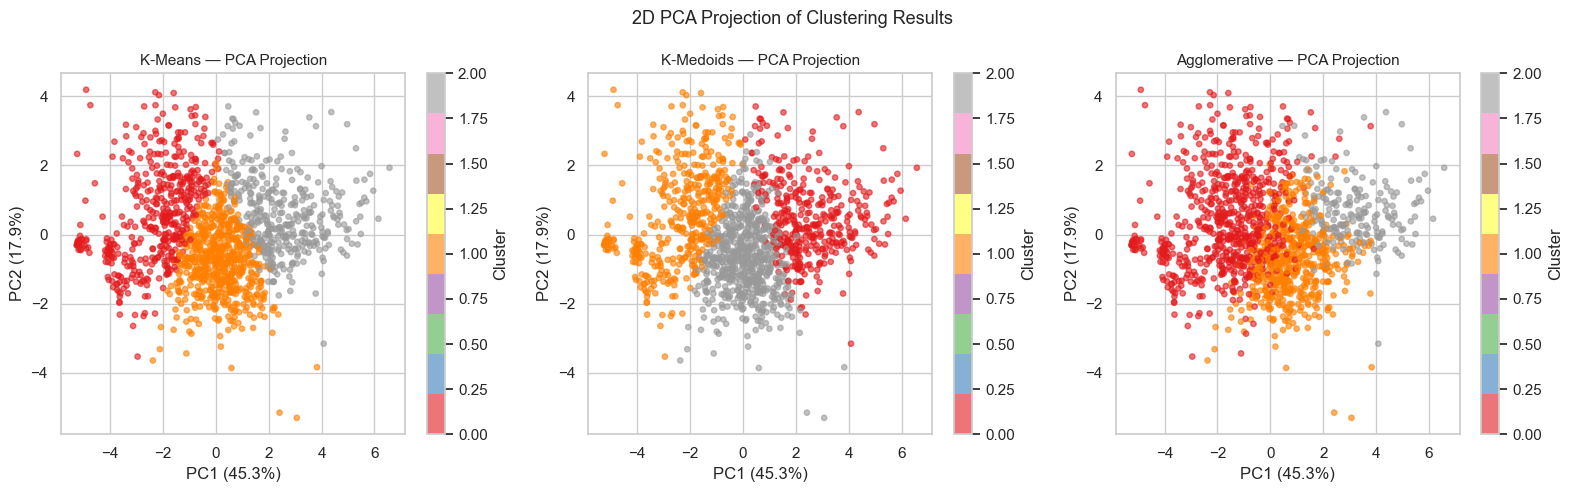

In [4]:
# ─────────────────────────────────────────────
# PCA reduces the 10-dimensional feature space to 2D.
# This allows us to visualise cluster separation in 2D
# while preserving as much variance as possible.
# ─────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(scaled_data)

print(f"PCA variance explained: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in zip(axes, ['kmeans_cluster', 'kmedoids_cluster', 'agg_cluster'],
                                 ['K-Means', 'K-Medoids', 'Agglomerative']):
    scatter = ax.scatter(
        pca_coords[:, 0], pca_coords[:, 1],
        c=df[col], cmap='Set1', alpha=0.6, s=15
    )
    ax.set_title(f"{title} — PCA Projection", fontsize=11)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.suptitle("2D PCA Projection of Clustering Results", fontsize=13)
plt.tight_layout()
plt.show()

---
## Part C: Cluster-wise Time-Series Trends

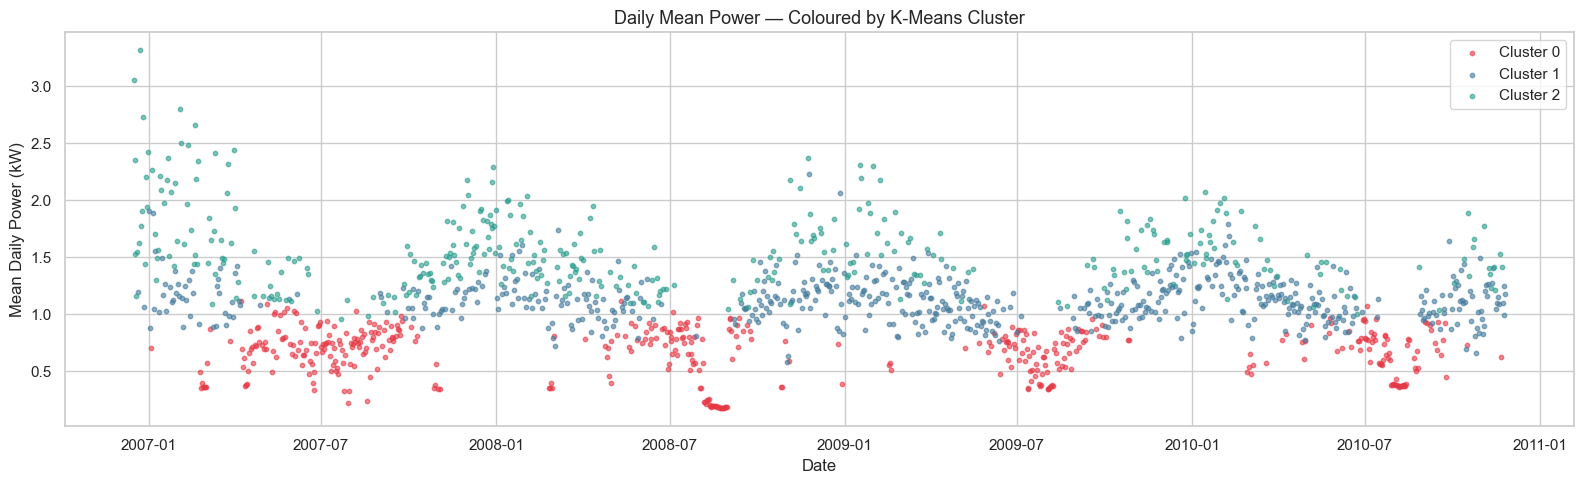

In [5]:
# ─────────────────────────────────────────────
# Time-series of mean_power coloured by K-Means cluster
# This reveals WHEN each cluster dominates — seasonal patterns,
# holiday periods, and year-to-year shifts.
# ─────────────────────────────────────────────
cluster_colors = {0: '#e63946', 1: '#457b9d', 2: '#2a9d8f'}

fig, ax = plt.subplots(figsize=(16, 5))

for cluster_id, color in cluster_colors.items():
    mask = df['kmeans_cluster'] == cluster_id
    ax.scatter(
        df.index[mask], df.loc[mask, 'mean_power'],
        color=color, alpha=0.6, s=10,
        label=f'Cluster {cluster_id}'
    )

ax.set_title("Daily Mean Power — Coloured by K-Means Cluster", fontsize=13)
ax.set_ylabel("Mean Daily Power (kW)")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
plt.show()

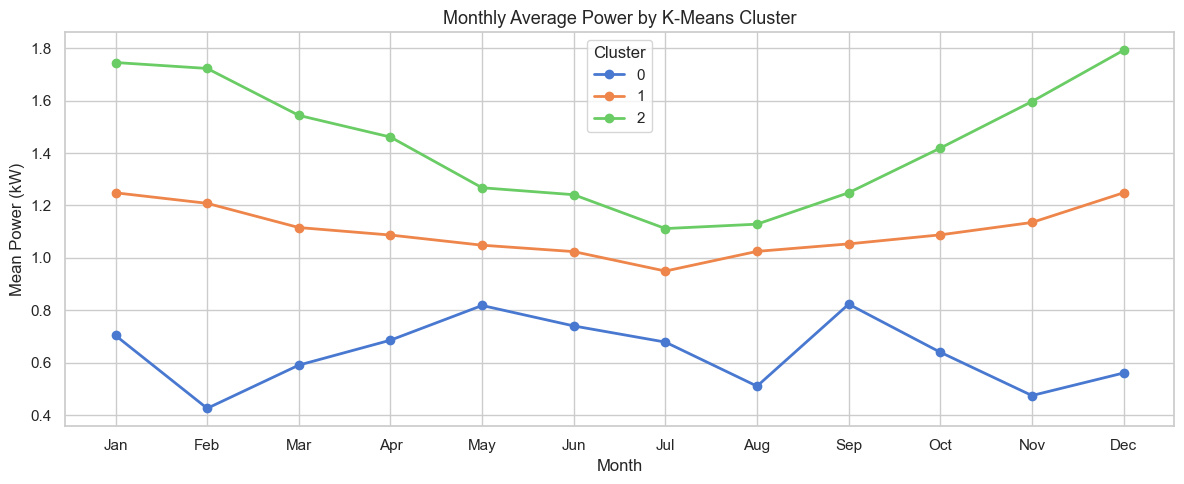

In [6]:
# ─────────────────────────────────────────────
# Monthly aggregation of power per cluster
# Shows seasonal consumption patterns within each cluster
# ─────────────────────────────────────────────
df['month'] = df.index.month
monthly_cluster = df.groupby(['month', 'kmeans_cluster'])['mean_power'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 5))
monthly_cluster.plot(ax=ax, marker='o', linewidth=2)
ax.set_title("Monthly Average Power by K-Means Cluster", fontsize=13)
ax.set_xlabel("Month")
ax.set_ylabel("Mean Power (kW)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend(title='Cluster')
plt.tight_layout()
plt.show()

---
## Part D: Feature Heatmap per Cluster

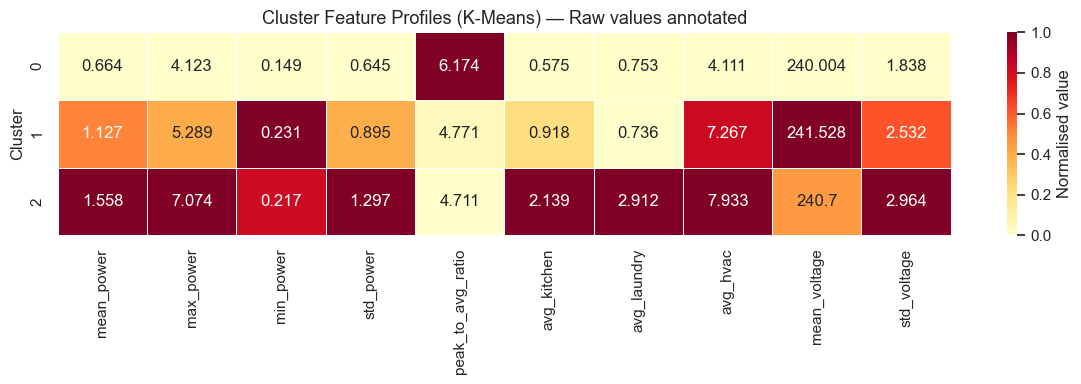

In [7]:
# ─────────────────────────────────────────────
# Heatmap of normalised mean feature values per cluster.
# This is the most informative plot for interpretation:
# it shows which features distinguish each cluster from the others.
# ─────────────────────────────────────────────
feature_cols = [
    'mean_power', 'max_power', 'min_power', 'std_power',
    'peak_to_avg_ratio', 'avg_kitchen', 'avg_laundry', 'avg_hvac',
    'mean_voltage', 'std_voltage'
]

cluster_profiles = df.groupby('kmeans_cluster')[feature_cols].mean()

# Normalise each feature to [0, 1] for fair visual comparison
cluster_profiles_norm = (cluster_profiles - cluster_profiles.min()) / \
                        (cluster_profiles.max() - cluster_profiles.min())

plt.figure(figsize=(12, 4))
sns.heatmap(
    cluster_profiles_norm,
    annot=cluster_profiles.round(3),
    fmt='',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Normalised value'}
)
plt.title("Cluster Feature Profiles (K-Means) — Raw values annotated", fontsize=13)
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

---
## Part E: DBSCAN Noise Point Analysis

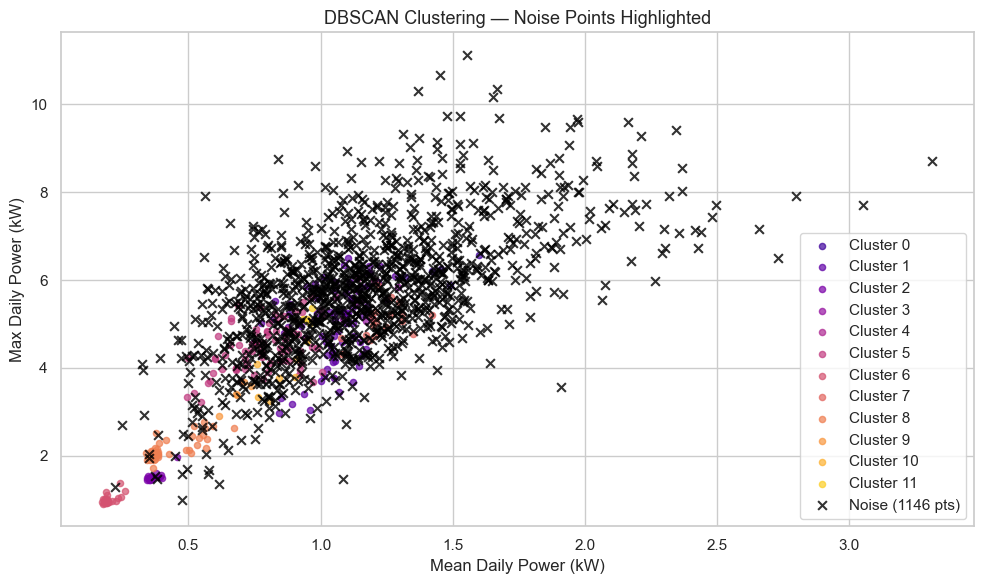

Noise point dates:
['2006-12-16', '2006-12-17', '2006-12-18', '2006-12-19', '2006-12-20', '2006-12-21', '2006-12-22', '2006-12-23', '2006-12-24', '2006-12-25', '2006-12-26', '2006-12-27', '2006-12-28', '2006-12-29', '2006-12-30', '2006-12-31', '2007-01-01', '2007-01-02', '2007-01-03', '2007-01-04', '2007-01-05', '2007-01-06', '2007-01-07', '2007-01-08', '2007-01-09', '2007-01-10', '2007-01-11', '2007-01-12', '2007-01-13', '2007-01-14', '2007-01-15', '2007-01-16', '2007-01-17', '2007-01-18', '2007-01-19', '2007-01-20', '2007-01-21', '2007-01-22', '2007-01-23', '2007-01-24', '2007-01-25', '2007-01-28', '2007-01-29', '2007-01-31', '2007-02-01', '2007-02-02', '2007-02-03', '2007-02-04', '2007-02-05', '2007-02-06', '2007-02-07', '2007-02-09', '2007-02-10', '2007-02-11', '2007-02-12', '2007-02-13', '2007-02-14', '2007-02-15', '2007-02-17', '2007-02-18', '2007-02-19', '2007-02-20', '2007-02-21', '2007-02-22', '2007-02-23', '2007-02-24', '2007-03-03', '2007-03-04', '2007-03-05', '2007-03-06', 

In [8]:
# ─────────────────────────────────────────────
# Visualise DBSCAN output, properly separating noise points.
# Noise (label=-1) are days that do not belong to any dense cluster.
# These may represent unusual consumption events.
# ─────────────────────────────────────────────
is_noise = df['dbscan_cluster'] == -1
is_cluster = ~is_noise

fig, ax = plt.subplots(figsize=(10, 6))

# Plot clustered points (coloured by cluster)
unique_clusters = [l for l in sorted(df['dbscan_cluster'].unique()) if l != -1]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(unique_clusters)))

for cluster_id, color in zip(unique_clusters, colors):
    mask = df['dbscan_cluster'] == cluster_id
    ax.scatter(
        df.loc[mask, 'mean_power'], df.loc[mask, 'max_power'],
        c=[color], label=f'Cluster {cluster_id}', alpha=0.7, s=20
    )

# Plot noise points separately in black
ax.scatter(
    df.loc[is_noise, 'mean_power'], df.loc[is_noise, 'max_power'],
    c='black', marker='x', s=40, label=f'Noise ({is_noise.sum()} pts)', alpha=0.8, zorder=5
)

ax.set_title("DBSCAN Clustering — Noise Points Highlighted", fontsize=13)
ax.set_xlabel("Mean Daily Power (kW)")
ax.set_ylabel("Max Daily Power (kW)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Noise point dates:")
print(df.index[is_noise].strftime('%Y-%m-%d').tolist())

---
## Part F: Isolation Forest Anomaly Detection

In [9]:
# ─────────────────────────────────────────────
# Isolation Forest — unsupervised anomaly detection
# Works by randomly partitioning data using random trees.
# Points that require fewer splits to isolate = anomalies.
# contamination=0.05 → assume ~5% of days are anomalous.
# Output: +1 = normal, -1 = anomaly
# ─────────────────────────────────────────────
iso_forest = IsolationForest(contamination=0.05, random_state=42, n_estimators=200)
anomaly_labels = iso_forest.fit_predict(scaled_data)
anomaly_scores = iso_forest.decision_function(scaled_data)  # Lower = more anomalous

df['anomaly'] = anomaly_labels
df['anomaly_score'] = anomaly_scores

n_anomalies = (anomaly_labels == -1).sum()
print(f"Anomalies detected: {n_anomalies} ({n_anomalies/len(df)*100:.1f}% of days)")

Anomalies detected: 72 (5.0% of days)


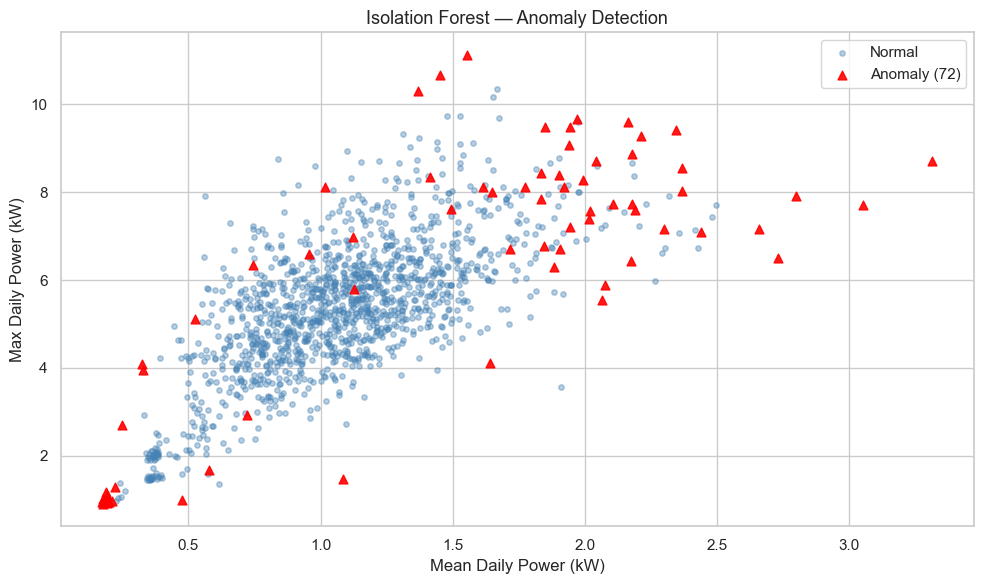

In [10]:
# ─────────────────────────────────────────────
# Anomaly Visualisation 1: Scatter plot
# Anomalous days shown in red, normal days in grey
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

normal = df['anomaly'] == 1
anomaly = df['anomaly'] == -1

ax.scatter(df.loc[normal, 'mean_power'], df.loc[normal, 'max_power'],
           c='steelblue', alpha=0.4, s=15, label='Normal')
ax.scatter(df.loc[anomaly, 'mean_power'], df.loc[anomaly, 'max_power'],
           c='red', alpha=0.9, s=40, marker='^', label=f'Anomaly ({n_anomalies})')

ax.set_title("Isolation Forest — Anomaly Detection", fontsize=13)
ax.set_xlabel("Mean Daily Power (kW)")
ax.set_ylabel("Max Daily Power (kW)")
ax.legend()
plt.tight_layout()
plt.show()

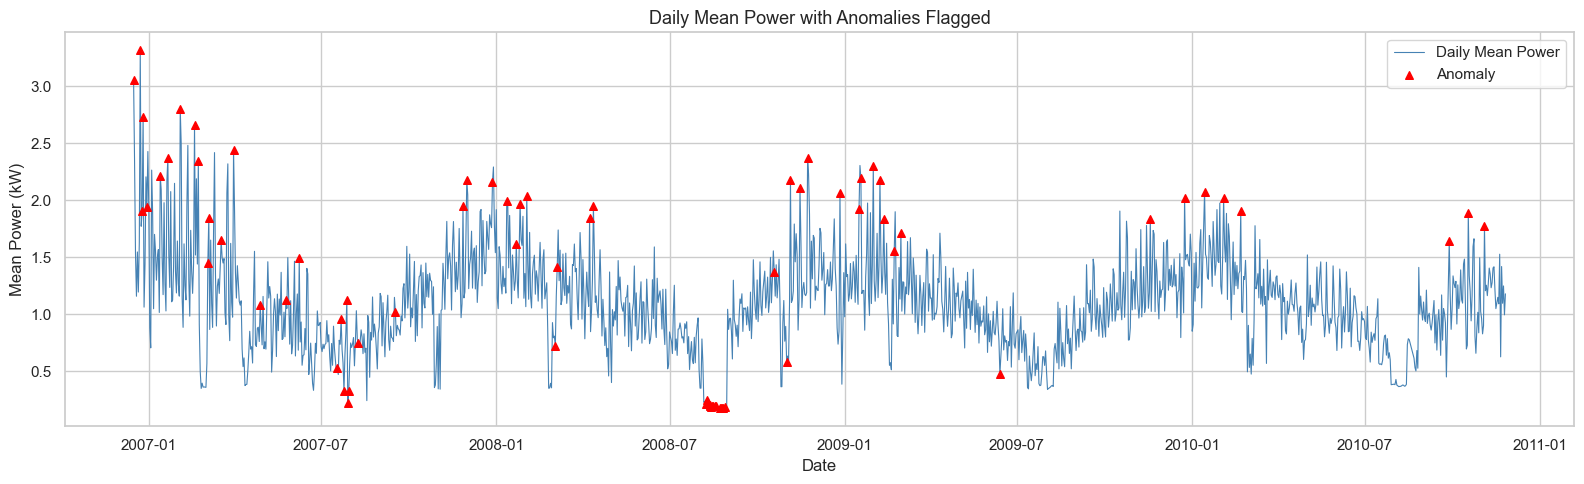

In [11]:
# ─────────────────────────────────────────────
# Anomaly Visualisation 2: Time-series with anomalies flagged
# Helps identify WHEN anomalies occur (e.g., holidays, extreme weather)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df.index, df['mean_power'], color='steelblue', linewidth=0.8, label='Daily Mean Power')

# Overlay anomaly points
ax.scatter(
    df.index[anomaly], df.loc[anomaly, 'mean_power'],
    color='red', zorder=5, s=30, label='Anomaly', marker='^'
)

ax.set_title("Daily Mean Power with Anomalies Flagged", fontsize=13)
ax.set_ylabel("Mean Power (kW)")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# ─────────────────────────────────────────────
# Print top 10 most anomalous days
# These are the days the model considers most unusual.
# Sorting by anomaly_score ascending → lowest score = most anomalous
# ─────────────────────────────────────────────
top_anomalies = df[df['anomaly'] == -1].sort_values('anomaly_score').head(10)
print("Top 10 most anomalous days:")
print(top_anomalies[['mean_power', 'max_power', 'std_power', 'anomaly_score']].round(3).to_string())

Top 10 most anomalous days:
            mean_power  max_power  std_power  anomaly_score
datetime                                                   
2008-11-05       2.177      8.862      1.658         -0.104
2007-01-21       2.366      8.018      1.855         -0.103
2007-04-28       1.083      1.478      0.428         -0.098
2010-11-04       1.774      8.126      1.702         -0.096
2007-01-13       2.213      9.272      1.901         -0.088
2009-02-22       1.554     11.122      1.863         -0.067
2009-01-31       2.301      7.164      1.725         -0.066
2008-11-23       2.366      8.556      1.978         -0.066
2007-02-18       2.660      7.160      1.558         -0.065
2007-03-05       1.847      9.486      1.688         -0.055


In [13]:
# ─────────────────────────────────────────────
# Save final labelled dataset
# ─────────────────────────────────────────────
df.to_csv("final_labelled_features.csv")
print("Final dataset with cluster labels and anomaly flags saved.")

Final dataset with cluster labels and anomaly flags saved.
